# Notebook 5: Hybrid LSTM-SNP (Fuzzy Feature Aug + Fuzzy Gates)

**Dataset**: Monthly Lake Erie Levels

## Description
This notebook implements the **hybrid model** that combines:
1. **Fuzzy Feature Augmentation** (from Notebook 2): Input is augmented with fuzzy-derived features
2. **Fuzzy Gate Replacement** (from Notebook 3): Gates use fuzzy inference instead of sigmoid

This represents the most complex integration of fuzzy logic with LSTM-SNP. Gradient clipping 
(norm=1.0) and careful weight initialization are applied for training stability.

The interaction between input-level and gate-level fuzzy reasoning is documented and analyzed.

## Theory: Hybrid Fuzzy LSTM-SNP

This model combines two fuzzy integration strategies:

### 1. Input-Level: Fuzzy Feature Augmentation
Same as Notebook 2:
- Fuzzy inference on $x(t)$ and $x(t-1)$
- Augmented input: $x'(t) = [x(t), y_{fuzzy}]$
- Input dimension becomes 2

### 2. Gate-Level: Fuzzy Gate Replacement
Same as Notebook 3:
- Gates r, c, o computed via fuzzy inference
- Fixed Gaussian MFs, trainable consequent parameters
- Generation gate a retains tanh

### Interaction Between Levels
- The fuzzy-augmented input provides richer information to the cell
- The fuzzy gates process this enriched input with adaptive, rule-based gating
- This creates a two-level fuzzy reasoning pipeline

### Stability Measures
- Gradient clipping (norm ≤ 1.0)
- Careful weight initialization
- Fuzzy weights are clipped to valid ranges

## Model Architecture & Implementation

In [1]:
# ============================================================
# ALL IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import Model
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.4.2


### Fuzzy Inference System (NumPy — for preprocessing)

In [2]:
# ============================================================
# Fuzzy Inference System (NumPy — for preprocessing)
#
# Fixed Gaussian membership functions:
#   μ_low(x)  = exp(-(x - (-1))² / (2·0.5²))
#   μ_high(x) = exp(-(x - (+1))² / (2·0.5²))
#
# 4 Takagi-Sugeno rules with fixed consequent parameters:
#   IF x(t) is low  AND x(t-1) is low  → y₁ = 0.5·x(t) + 0.5·x(t-1)
#   IF x(t) is low  AND x(t-1) is high → y₂ = 0.7·x(t) + 0.3·x(t-1) - 0.1
#   IF x(t) is high AND x(t-1) is low  → y₃ = 0.3·x(t) + 0.7·x(t-1) + 0.1
#   IF x(t) is high AND x(t-1) is high → y₄ = 0.5·x(t) + 0.5·x(t-1)
#
# Output: y = Σ(wᵢ·yᵢ) / Σ(wᵢ)
# ============================================================

def gaussian_mf(x, center, sigma=0.5):
    """Fixed Gaussian membership function."""
    return np.exp(-(x - center)**2 / (2 * sigma**2))

def fuzzy_inference_numpy(x_t, x_tm1):
    """
    Compute fuzzy feature from x(t) and x(t-1).
    Uses fixed membership functions and fixed consequent parameters.
    """
    # Membership degrees
    mu_low_xt = gaussian_mf(x_t, center=-1.0)
    mu_high_xt = gaussian_mf(x_t, center=1.0)
    mu_low_xtm1 = gaussian_mf(x_tm1, center=-1.0)
    mu_high_xtm1 = gaussian_mf(x_tm1, center=1.0)

    # Rule firing strengths (product)
    w1 = mu_low_xt * mu_low_xtm1      # low-low
    w2 = mu_low_xt * mu_high_xtm1     # low-high
    w3 = mu_high_xt * mu_low_xtm1     # high-low
    w4 = mu_high_xt * mu_high_xtm1    # high-high

    # Consequent outputs (fixed linear functions)
    y1 = 0.5 * x_t + 0.5 * x_tm1
    y2 = 0.7 * x_t + 0.3 * x_tm1 - 0.1
    y3 = 0.3 * x_t + 0.7 * x_tm1 + 0.1
    y4 = 0.5 * x_t + 0.5 * x_tm1

    # Weighted average defuzzification
    numerator = w1 * y1 + w2 * y2 + w3 * y3 + w4 * y4
    denominator = w1 + w2 + w3 + w4 + 1e-8

    return numerator / denominator

### Fuzzy Gate LSTM-SNP Cell

In [3]:
# ============================================================
# Fuzzy Gate LSTM-SNP Cell
# Gates r, c, o use fuzzy inference instead of hard sigmoid.
# Generation gate 'a' keeps tanh (unchanged).
#
# Fixed Gaussian membership functions:
#   μ_low(x)  = exp(-(x - (-1))² / (2·0.5²))
#   μ_high(x) = exp(-(x - (+1))² / (2·0.5²))
#
# Each gate uses 2 Takagi-Sugeno rules with trainable consequents.
# ============================================================

@tf.keras.utils.register_keras_serializable()
class FuzzyLSTMSNPCell(layers.Layer):
    """
    LSTM-SNP Cell with fuzzy gate replacement.
    Gates r, c, o are computed via fuzzy inference.
    Gate a keeps tanh activation.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units
        self.activation = tf.keras.activations.get('tanh')
        # Fixed membership function parameters
        self.mu_low = -1.0
        self.mu_high = 1.0
        self.sigma = 0.5

    def build(self, input_shape):
        input_dim = input_shape[-1]

        # Standard weights for pre-activation computation
        # 4 gates: r, c, o, a
        self.kernel = self.add_weight(
            shape=(input_dim, self.units * 4),
            initializer='glorot_uniform',
            name='kernel'
        )
        self.recurrent_kernel = self.add_weight(
            shape=(self.units, self.units * 4),
            initializer='orthogonal',
            name='recurrent_kernel'
        )
        self.bias = self.add_weight(
            shape=(self.units * 4,),
            initializer='zeros',
            name='bias'
        )

        # Fuzzy consequent parameters for 3 gates (r, c, o)
        # Each gate has 2 rules, each rule has 3 params (a, b, c_param)
        # rule_i: y_i = a_i * z_gate + b_i * u_mean + c_i
        # Store as instance attributes for reliable access
        self.fuzzy_params = {}
        for gate_name in ['r', 'c', 'o']:
            self.fuzzy_params[gate_name] = {}
            for rule_idx in range(2):
                self.fuzzy_params[gate_name][rule_idx] = {
                    'a': self.add_weight(
                        shape=(self.units,),
                        initializer=tf.keras.initializers.RandomUniform(-0.1, 0.1),
                        name=f'fuzzy_{gate_name}_rule{rule_idx}_a'
                    ),
                    'b': self.add_weight(
                        shape=(self.units,),
                        initializer=tf.keras.initializers.RandomUniform(-0.1, 0.1),
                        name=f'fuzzy_{gate_name}_rule{rule_idx}_b'
                    ),
                    'c_param': self.add_weight(
                        shape=(self.units,),
                        initializer=tf.keras.initializers.Zeros(),
                        name=f'fuzzy_{gate_name}_rule{rule_idx}_c'
                    ),
                }

    def _gaussian_mf(self, x, center):
        """Fixed Gaussian membership function."""
        return tf.exp(-tf.square(x - center) / (2.0 * self.sigma ** 2))

    def _fuzzy_gate(self, z_gate, u_mean, gate_name):
        """Compute gate value via fuzzy inference (2 rules)."""
        # Membership degrees (fixed)
        w_low = self._gaussian_mf(z_gate, self.mu_low)
        w_high = self._gaussian_mf(z_gate, self.mu_high)

        # Get trainable consequent parameters from instance dict
        p = self.fuzzy_params[gate_name]

        # Rule outputs (trainable linear consequents)
        y0 = p[0]['a'] * z_gate + p[0]['b'] * u_mean + p[0]['c_param']
        y1 = p[1]['a'] * z_gate + p[1]['b'] * u_mean + p[1]['c_param']

        # Weighted average defuzzification
        numerator = w_low * y0 + w_high * y1
        denominator = w_low + w_high + 1e-8
        output = numerator / denominator

        # Clip to [0, 1] since gates should be bounded
        return tf.clip_by_value(output, 0.0, 1.0)

    def call(self, inputs, states):
        u_tm1 = states[0]

        z = tf.matmul(inputs, self.kernel) + \
            tf.matmul(u_tm1, self.recurrent_kernel) + self.bias

        z0 = z[:, :self.units]
        z1 = z[:, self.units:2*self.units]
        z2 = z[:, 2*self.units:3*self.units]
        z3 = z[:, 3*self.units:]

        # Mean of previous state for fuzzy rule input
        u_mean = tf.reduce_mean(u_tm1, axis=-1, keepdims=True)
        u_mean = tf.tile(u_mean, [1, self.units])

        # Fuzzy gates
        r = self._fuzzy_gate(z0, u_mean, 'r')
        c = self._fuzzy_gate(z1, u_mean, 'c')
        o = self._fuzzy_gate(z2, u_mean, 'o')
        a = self.activation(z3)  # tanh unchanged

        u = r * u_tm1 - c * a
        h = o * a

        return h, [u]

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config

### Build Model

In [4]:
# ============================================================
# Model Construction: Hybrid LSTM-SNP
# Combines: Fuzzy Feature Augmentation + Fuzzy Gate Replacement
# input_dim=2, FuzzyLSTMSNPCell, gradient clipping.
# ============================================================

def build_model(input_dim, units, batch_size):
    cell = FuzzyLSTMSNPCell(units)
    rnn = layers.RNN(cell, return_sequences=False, stateful=True)

    inputs = tf.keras.Input(batch_shape=(batch_size, 1, input_dim))
    x = rnn(inputs)
    outputs = layers.Dense(1)(x)

    model = tf.keras.Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

In [5]:
# Quick model check
model = build_model(input_dim=2, units=8, batch_size=1)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (1, 1, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (RNN)                       │ (1, 8)                 │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 1)                 │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 505 (1.97 KB)

 Trainable params: 505 (1.97 KB)

 Non-trainable params: 0 (0.00 B)

## Data Pipeline — Monthly Lake Erie Levels

In [6]:
# ============================================================
# 1. Load Time Series Data
# ============================================================

series = pd.read_csv(
    'content/monthly-lake-erie-levels-1921-19.csv',
    header=0,
    parse_dates=[0],
    index_col=0
)

raw_values = series.values.flatten()
print(f"Data shape: {raw_values.shape}")
print(f"First 5 values: {raw_values[:5]}")

Data shape: (600,)
First 5 values: [14.763 14.649 15.085 16.376 16.926]


In [7]:
# ============================================================
# 2. First-Order Differencing
# ============================================================

def difference(dataset, interval=1):
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)

diff_values = difference(raw_values, 1)

In [8]:
# ============================================================
# 3. Convert to Supervised Learning Format (lag=2)
#    Needed for fuzzy feature augmentation: x(t), x(t-1)
# ============================================================

def timeseries_to_supervised(data, lag=1):
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values

supervised = timeseries_to_supervised(diff_values, 2)
print(f"Supervised data shape: {supervised.shape}")

Supervised data shape: (599, 3)


In [9]:
# ============================================================
# 4. Train-Test Split
# ============================================================

train, test = supervised[:-60], supervised[-60:]
print(f"Train: {train.shape}, Test: {test.shape}")

# ============================================================
# 5. Feature Scaling
# ============================================================

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(train)

train_scaled = scaler.transform(train)
test_scaled = scaler.transform(test)

Train: (539, 3), Test: (60, 3)


In [10]:
# ============================================================
# 6. Reshape for RNN Input (with Fuzzy Feature Augmentation)
#    supervised columns: [x(t-2), x(t-1), x(t)]
#    We use x(t-1) as primary input, x(t-2) for fuzzy context
# ============================================================

# Extract columns: col0=x(t-2), col1=x(t-1), col2=x(t) (target)
X_train_raw = train_scaled[:, 0:-1]  # [x(t-2), x(t-1)]
y_train = train_scaled[:, -1]        # x(t)

X_test_raw = test_scaled[:, 0:-1]
y_test = test_scaled[:, -1]

# Compute fuzzy features for training data
X_train_fuzzy = np.zeros((X_train_raw.shape[0], 2))  # [x(t-1), y_fuzzy]
for i in range(X_train_raw.shape[0]):
    x_t = X_train_raw[i, 1]      # x(t-1) = current input
    x_tm1 = X_train_raw[i, 0]    # x(t-2) = previous input
    y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
    X_train_fuzzy[i, 0] = x_t
    X_train_fuzzy[i, 1] = y_fuzz

X_train = X_train_fuzzy.reshape((X_train_fuzzy.shape[0], 1, 2))

# Compute fuzzy features for test data
X_test_fuzzy = np.zeros((X_test_raw.shape[0], 2))
for i in range(X_test_raw.shape[0]):
    x_t = X_test_raw[i, 1]
    x_tm1 = X_test_raw[i, 0]
    y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
    X_test_fuzzy[i, 0] = x_t
    X_test_fuzzy[i, 1] = y_fuzz

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (539, 1, 2), y_train shape: (539,)


## Training Loop

In [11]:
# ============================================================
# 30-Run Experiment Protocol
# ============================================================

all_rmse = []
all_mse = []
all_nmse = []
all_predictions = []
all_losses = []

for run in range(30):
    print(f'\n===== RUN {run+1}/30 =====')

    np.random.seed(run)
    tf.random.set_seed(run)

    tf.keras.backend.clear_session()
    model = build_model(input_dim=2, units=8, batch_size=1)

    rnn_layer = model.layers[1]

    # Training with manual epoch loop + reset_states
    run_losses = []
    for epoch in range(100):
        history = model.fit(
            X_train, y_train,
            epochs=1, batch_size=1,
            verbose=0, shuffle=False
        )
        run_losses.append(history.history['loss'][0])
        rnn_layer.reset_states()

    all_losses.append(run_losses)
    print(f'Training complete for run {run+1}')

    # Warm-up: condition hidden states on training data
    for i in range(len(train_scaled)):
        X_raw = train_scaled[i, 0:-1]
        x_t = X_raw[1]
        x_tm1 = X_raw[0]
        y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
        X_aug = np.array([x_t, y_fuzz]).reshape(1, 1, 2)
        model.predict(X_aug, batch_size=1, verbose=0)

    # Test predictions (single-step) with fuzzy feature augmentation
    predictions = []
    for i in range(len(test_scaled)):
        X_raw = test_scaled[i, 0:-1]  # [x(t-2), x(t-1)]
        x_t = X_raw[1]      # current input
        x_tm1 = X_raw[0]    # previous input
        y_fuzz = fuzzy_inference_numpy(x_t, x_tm1)
        X_aug = np.array([x_t, y_fuzz]).reshape(1, 1, 2)
        yhat = model.predict(X_aug, batch_size=1, verbose=0)[0, 0]

        # Invert scaling (need to match the scaler's column structure)
        # Scaler was fit on 3-column data [x(t-2), x(t-1), x(t)]
        new_row = list(X_raw) + [yhat]
        array = np.array(new_row).reshape(1, len(new_row))
        inverted = scaler.inverse_transform(array)[0, -1]

        # Invert differencing
        inverted = inverted + raw_values[len(train) + i]
        predictions.append(inverted)

        expected = raw_values[len(train) + i + 1]
        print(f'Month={i+1}, Predicted={inverted:.4f}, Expected={expected:.4f}')

    # Compute metrics
    actual = raw_values[-60:]
    rmse = sqrt(mean_squared_error(actual, predictions))
    mse = mean_squared_error(actual, predictions)
    meanV = np.mean(actual)
    dominator = np.linalg.norm(np.array(predictions) - meanV, 2)
    nmse = mse / np.power(dominator, 2)

    all_rmse.append(rmse)
    all_mse.append(mse)
    all_nmse.append(nmse)
    all_predictions.append(predictions)

    print(f'Run {run+1} — RMSE: {rmse:.6f}, MSE: {mse:.6f}, NMSE: {nmse:.10f}')


===== RUN 1/30 =====

Training complete for run 1
Month=1, Predicted=13.4154, Expected=13.7000
Month=2, Predicted=14.2289, Expected=13.8140
Month=3, Predicted=13.8885, Expected=14.3830
Month=4, Predicted=14.6775, Expected=15.0470
Month=5, Predicted=15.4575, Expected=15.6930
Month=6, Predicted=15.9632, Expected=15.8440
Month=7, Predicted=15.8514, Expected=15.7120
Month=8, Predicted=15.5239, Expected=15.3130
Month=9, Predicted=14.9926, Expected=14.7630
Month=10, Predicted=14.3840, Expected=13.5480
Month=11, Predicted=12.8406, Expected=13.5860
Month=12, Predicted=13.8799, Expected=14.5160
Month=13, Predicted=15.6939, Expected=14.3830
Month=14, Predicted=14.3324, Expected=14.4970
Month=15, Predicted=14.4001, Expected=14.7440
Month=16, Predicted=14.9991, Expected=15.8060
Month=17, Predicted=16.3842, Expected=16.5270
Month=18, Predicted=16.8080, Expected=16.5460
Month=19, Predicted=16.4514, Expected=16.7170
Month=20, Predicted=16.7097, Expected=16.4330
Month=21, Predicted=16.2640, Expected=

## Results

In [12]:
# ============================================================
# Summary Statistics (30 runs)
# ============================================================

print('\n===== FINAL RESULTS — Hybrid (Feature Aug + Gate) on Monthly Lake Erie Levels (30 runs) =====')
print(f'RMSE: {np.mean(all_rmse):.6f} ± {np.std(all_rmse):.6f}')
print(f'MSE:  {np.mean(all_mse):.6f} ± {np.std(all_mse):.6f}')
print(f'NMSE: {np.mean(all_nmse):.10f} ± {np.std(all_nmse):.10f}')

best_idx = np.argmin(all_rmse)
print(f'\nBest run: {best_idx+1}')
print(f'  RMSE: {all_rmse[best_idx]:.6f}')
print(f'  MSE:  {all_mse[best_idx]:.6f}')
print(f'  NMSE: {all_nmse[best_idx]:.10f}')


===== FINAL RESULTS — Hybrid (Feature Aug + Gate) on Monthly Lake Erie Levels (30 runs) =====
RMSE: 0.487172 ± 0.006408
MSE:  0.237377 ± 0.006280
NMSE: 0.0019367507 ± 0.0000726039

Best run: 7
  RMSE: 0.479678
  MSE:  0.230091
  NMSE: 0.0019015696


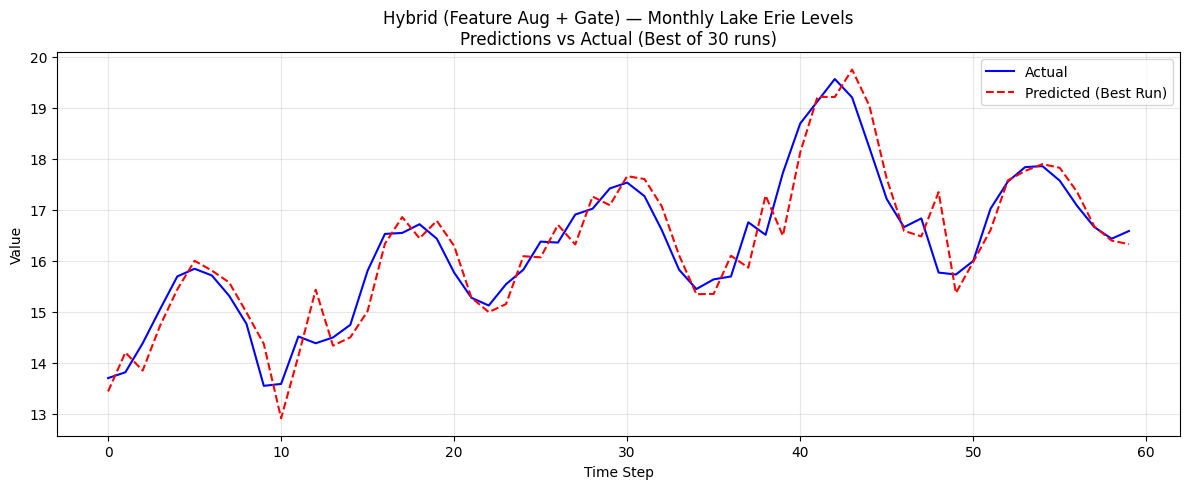

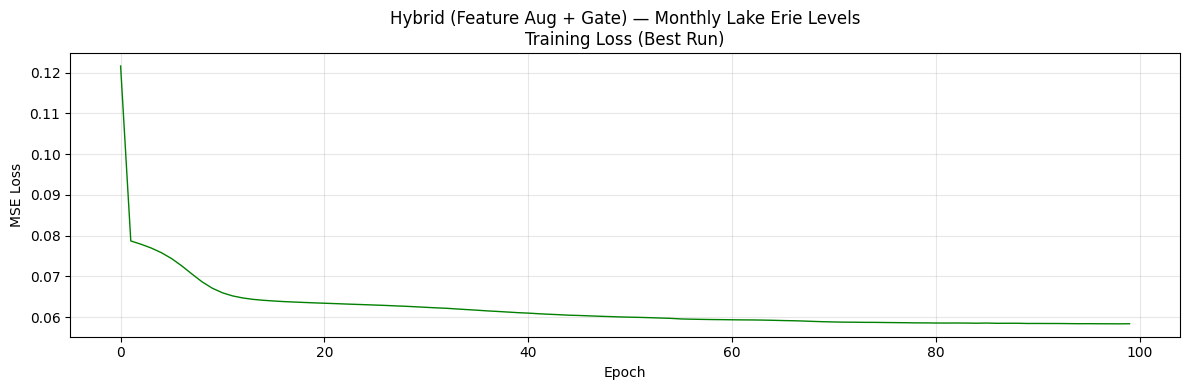

=== Best Run Metrics ===
RMSE: 0.479678
MSE:  0.230091
NMSE: 0.0019015696


In [13]:
# ============================================================
# Predictions vs Actual (Best Run)
# ============================================================

actual = raw_values[-60:]
best_predictions = all_predictions[best_idx]

plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_predictions, label='Predicted (Best Run)', color='red',
         linewidth=1.5, linestyle='--')
plt.title('Hybrid (Feature Aug + Gate) — Monthly Lake Erie Levels\nPredictions vs Actual (Best of 30 runs)')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Loss Curve (Best Run)
# ============================================================

plt.figure(figsize=(12, 4))
plt.plot(all_losses[best_idx], color='green', linewidth=1.0)
plt.title('Hybrid (Feature Aug + Gate) — Monthly Lake Erie Levels\nTraining Loss (Best Run)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Final Metrics Summary
# ============================================================

print('=== Best Run Metrics ===')
print(f'RMSE: {all_rmse[best_idx]:.6f}')
print(f'MSE:  {all_mse[best_idx]:.6f}')
print(f'NMSE: {all_nmse[best_idx]:.10f}')

## Observations

### Hybrid (Feature Aug + Gate) on Monthly Lake Erie Levels

**Run the notebook to generate results and fill in observations:**

1. **Prediction Quality**: Compare RMSE/MSE/NMSE with other variants
2. **Training Stability**: Examine loss curves for convergence behavior
3. **Prediction Tracking**: Assess how well predictions track actual values
4. **Computational Cost**: Note training time per run

*After running all 5 variant notebooks, perform cross-variant comparison to evaluate 
whether fuzzy logic improves nonlinearity handling, interpretability, and prediction performance.*